# create a simple network

## Prepare - assuming persistent data set has been created in the previous notebook

In [1]:
from sympy import false

from src.general_utils import prepare_environment
from mri_dl import MRIUndersampledDataset, ResidualUNet, TrainConfig, train_model, load_checkpoint, predict_tensor
from torch.utils.data import DataLoader
import torch
import os
from pathlib import Path
import matplotlib.pyplot as plt

HPC = False
prepare_environment(hpc=HPC)

Data path: C:\mri_dataset\brain_age


## Create a dataset for a single plane, and a single retain ratio

In [2]:
data_sets_root = Path(os.getcwd() + r"/../reconstruction_dataset").resolve()

train_dataset = MRIUndersampledDataset(
    data_sets_root / "train",
    planes=("Coronal",),
    retain_ratios=(0.30,)
)

val_dataset = MRIUndersampledDataset(
    data_sets_root / "val",
    planes=("Coronal",),
    retain_ratios=(0.30,),
)

test_dataset = MRIUndersampledDataset(
    data_sets_root / "test",
    planes=("Coronal",),
    retain_ratios=(0.30,),
)

sample = train_dataset[0]

print(sample["sample_id"])
print(sample["input"].shape)
print(sample["target"].shape)
print(sample["delta_target"].shape)
print(sample["retain_ratio"])

Sub0113_Ses1_row001564_coronal_s0062_r30_u000
torch.Size([1, 99, 90])
torch.Size([1, 99, 90])
torch.Size([1, 99, 90])
tensor(0.3000)


## Show a sample

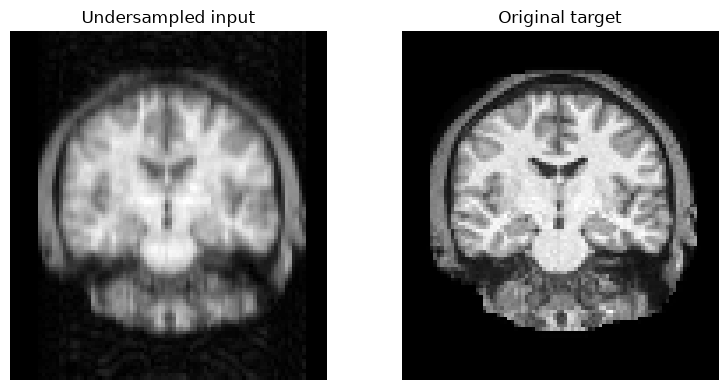

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(sample["input"][0], cmap="gray")
axes[0].set_title("Undersampled input")
axes[0].axis("off")

axes[1].imshow(sample["target"][0], cmap="gray")
axes[1].set_title("Original target")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Create data loader

In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

## Create a residual UNET model. Train it to predict the difference between the undersampled input and the original target.

In [5]:
train = False
if train:

    model_kwargs = {
        "in_channels": 1,
        "out_channels": 1,
        "base_channels": 16,
    }

    model = ResidualUNet(**model_kwargs)

    train_config = TrainConfig(
        epochs=60,
        learning_rate=5e-5,
        checkpoint_path="checkpoints/coronal_r30_delta_best.pt",
        seed=42,
        device=None,
    )

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        train_config=train_config,
        model_kwargs=model_kwargs,
    )

## Load the model

This can be used without training, if the model has already been trained and saved to a checkpoint.


MODEL EXECUTION TRACE
01. enc1.block.0 [Conv2d] | input=(1, 1, 256, 256) -> output=(1, 16, 256, 256)
02. enc1.block.1 [BatchNorm2d] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
03. enc1.block.2 [ReLU] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
04. enc1.block.3 [Conv2d] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
05. enc1.block.4 [BatchNorm2d] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
06. enc1.block.5 [ReLU] | input=(1, 16, 256, 256) -> output=(1, 16, 256, 256)
07. pool [MaxPool2d] | input=(1, 16, 256, 256) -> output=(1, 16, 128, 128)
08. enc2.block.0 [Conv2d] | input=(1, 16, 128, 128) -> output=(1, 32, 128, 128)
09. enc2.block.1 [BatchNorm2d] | input=(1, 32, 128, 128) -> output=(1, 32, 128, 128)
10. enc2.block.2 [ReLU] | input=(1, 32, 128, 128) -> output=(1, 32, 128, 128)
11. enc2.block.3 [Conv2d] | input=(1, 32, 128, 128) -> output=(1, 32, 128, 128)
12. enc2.block.4 [BatchNorm2d] | input=(1, 32, 128, 128) -> output=(1, 32, 128, 128)
13. enc2.

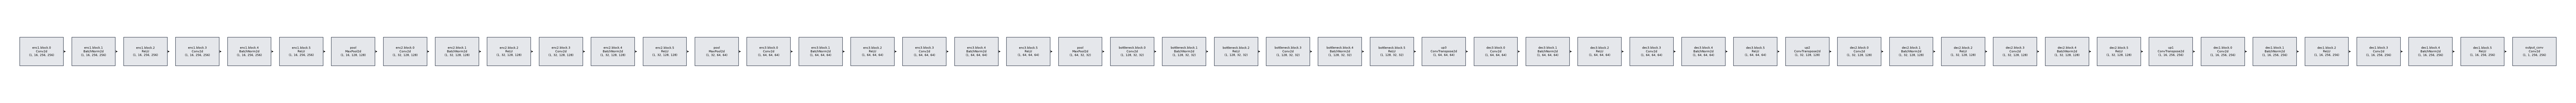

Saved graphical trace to: C:\Users\alonz\repos\studies\mri\final_project\mri_dl\residual_unet_traced_graph.png
Best epoch: 56
Best validation loss: 0.026654495298862456


In [6]:

loaded_model, checkpoint = load_checkpoint(
    checkpoint_path="checkpoints/coronal_r30_delta_best.pt",
    model_class=ResidualUNet,
)
loaded_model.visualize(graphical=True, show=True)

print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])

## Run inference on an example from test set

In [7]:
num_examples = min(5, len(test_dataset))
if num_examples == 0:
    raise ValueError("test_dataset is empty")
random_indices = torch.randperm(len(test_dataset))[:num_examples].tolist()

examples = []
for idx in random_indices:
    test_sample = test_dataset[idx]
    prediction = predict_tensor(
        model=loaded_model,
        input_tensor=test_sample["input"],
    )
    row = test_dataset.samples.iloc[idx]
    volume_name = Path(str(row["resolved_volume_path"])).name if "resolved_volume_path" in row.index else "unknown"
    slice_index = int(row["slice_index"]) if "slice_index" in row.index else -1
    examples.append(
        {
            "idx": idx,
            "sample": test_sample,
            "prediction": prediction,
            "volume_name": volume_name,
            "slice_index": slice_index,
        }
    )

print(f"Showing {len(examples)} random test samples: {random_indices}")

Showing 5 random test samples: [113, 66, 60, 183, 118]


## Show the prediction

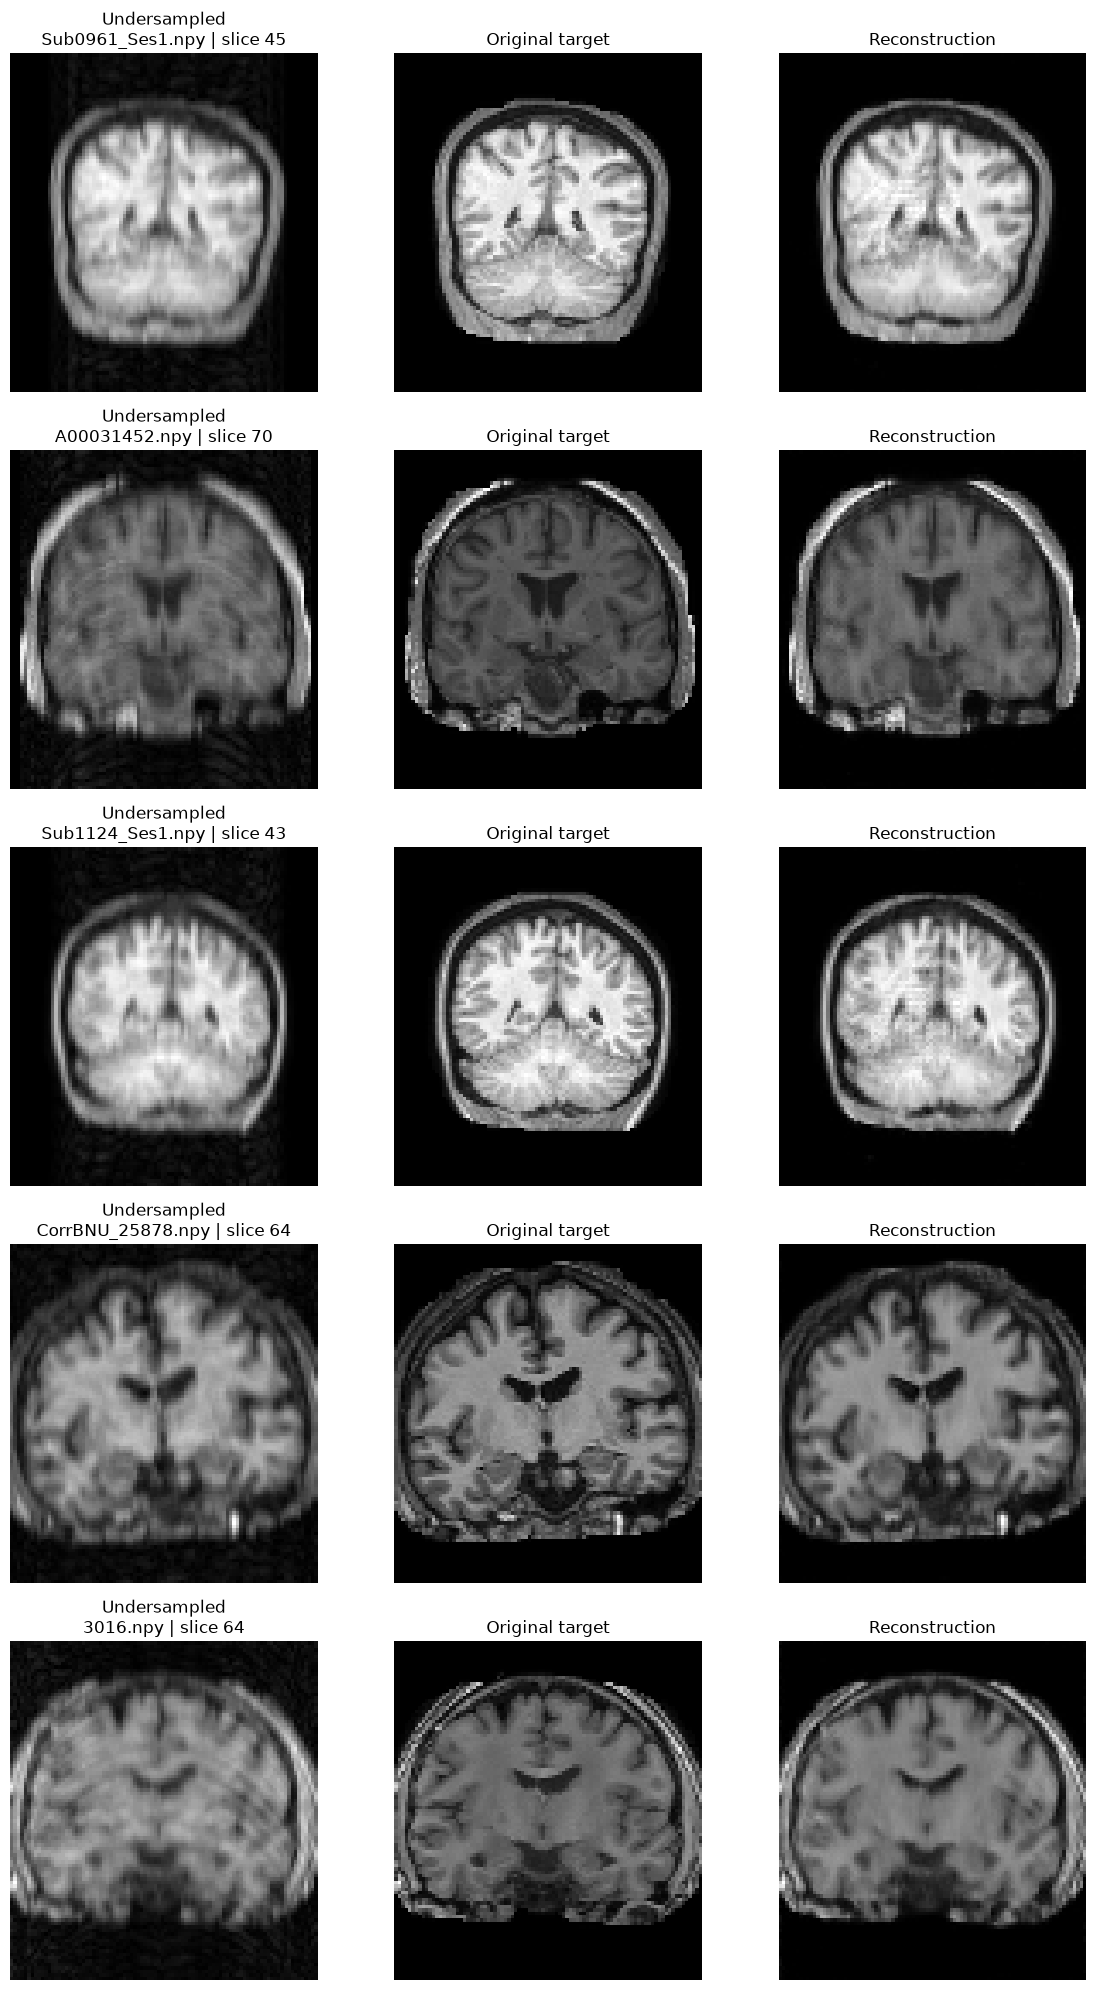

In [8]:
fig, axes = plt.subplots(len(examples), 3, figsize=(12, 4 * len(examples)))
if len(examples) == 1:
    axes = axes[None, ...]

for row_idx, example in enumerate(examples):
    test_sample = example["sample"]
    prediction = example["prediction"]
    volume_name = example["volume_name"]
    slice_index = example["slice_index"]

    axes[row_idx, 0].imshow(test_sample["input"][0], cmap="gray")
    axes[row_idx, 0].set_title(f"Undersampled\n{volume_name} | slice {slice_index}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(test_sample["target"][0], cmap="gray")
    axes[row_idx, 1].set_title("Original target")
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(prediction[0], cmap="gray")
    axes[row_idx, 2].set_title("Reconstruction")
    axes[row_idx, 2].axis("off")

plt.tight_layout()
plt.show()


## calculate the PSNR of the prediction

In [10]:
import pandas as pd
from src.metrices import calculate_psnr, calculate_ssim

rows = []
for example in examples:
    test_sample = example["sample"]
    prediction = example["prediction"]
    us_psnr = calculate_psnr(test_sample["target"][0].numpy(), test_sample["input"][0].numpy())
    rec_psnr = calculate_psnr(test_sample["target"][0].numpy(), prediction[0].numpy())
    us_ssim = calculate_ssim(test_sample["target"][0].numpy(), test_sample["input"][0].numpy())
    rec_ssim = calculate_ssim(test_sample["target"][0].numpy(), prediction[0].numpy())
    rows.append({
        "Volume": example["volume_name"],
        "Slice": example["slice_index"],
        "Undersampled PSNR": round(us_psnr, 3),
        "Reconstructed PSNR": round(rec_psnr, 3),
        "Undersampled SSIM": round(us_ssim, 4),
        "Reconstructed SSIM": round(rec_ssim, 4),
        "SSIM Gain": round(rec_ssim - us_ssim, 4),
        "Gain": round(rec_psnr - us_psnr, 3),
    })

# Append an average summary row
rows.append({
    "Volume": "AVERAGE",
    "Slice": "",
    "Undersampled PSNR": round(sum(r["Undersampled PSNR"] for r in rows) / len(rows), 3),
    "Reconstructed PSNR": round(sum(r["Reconstructed PSNR"] for r in rows) / len(rows), 3),
    "Undersampled SSIM": round(sum(r["Undersampled SSIM"] for r in rows) / len(rows), 4),
    "Reconstructed SSIM": round(sum(r["Reconstructed SSIM"] for r in rows) / len(rows), 4),
    "SSIM Gain": round(sum(r["SSIM Gain"] for r in rows) / len(rows), 4),
    "Gain": round(sum(r["Gain"] for r in rows) / len(rows), 3),
})

psnr_df = pd.DataFrame(rows).set_index(["Volume", "Slice"])
display(psnr_df.style.highlight_max(subset=["Reconstructed PSNR", "Gain"], color="lightgreen")
                      .highlight_max(subset=["Reconstructed SSIM", "SSIM Gain"], color="lightgreen")
                      .highlight_min(subset=["Gain"], color="lightyellow")
                      .highlight_min(subset=["SSIM Gain"], color="lightyellow")
                      .format({
                          "Undersampled PSNR": "{:.3f}",
                          "Reconstructed PSNR": "{:.3f}",
                          "Gain": "{:.3f}",
                          "Undersampled SSIM": "{:.4f}",
                          "Reconstructed SSIM": "{:.4f}",
                          "SSIM Gain": "{:.4f}",
                      }))


,,Undersampled PSNR,Reconstructed PSNR,Gain
Volume,Slice,,,
Sub0961_Ses1.npy,45,22.748,24.263,1.515
A00031452.npy,70,23.133,26.222,3.089
Sub1124_Ses1.npy,43,22.379,23.879,1.500
CorrBNU_25878.npy,64,23.828,25.141,1.312
3016.npy,64,23.443,25.735,2.292
AVERAGE,,23.106,25.048,1.942
